In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

In [25]:
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1)

        self.fc_mu = nn.Linear(64*7*7, latent_dim)
        self.fc_log_var = nn.Linear(64*7*7, latent_dim)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = x.view(x.size(0), -1)

        mu = self.fc_mu(x)
        log_var = self.fc_log_var(x)

        return mu, log_var


In [26]:
# Sampling

def reparameterized(mu, log_var):
        std = torch.exp(0.5 * log_var) # compute standared deviation
        eps = torch.randn_like(std) # eps is randomness 
        return mu + std * eps # sampling

In [27]:
# Decoder

class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()

        self.fc = nn.Linear(latent_dim, 64*7*7)

        self.deconv1 = nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1)
        self.deconv2 = nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1)

    def forward(self, z):
        x = self.fc(z)
        x = x.view(z.size(0), 64, 7, 7)

        x = F.relu(self.deconv1(x))
        x = torch.sigmoid(self.deconv2(x))

        return x

In [28]:
# CNN - VAE model

class VAE(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()

        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def forward(self, x):
        mu, log_var = self.encoder(x)
        z = reparameterized(mu, log_var)
        x_decoded = self.decoder(z)

        return x_decoded, mu, log_var

In [29]:
# Loss Function

def vae_loss(recon_x, x, mu, log_var):

    recon_loss = F.mse_loss(recon_x, x, reduction='sum')

    kl = -0.5 * torch.sum(
        1 + log_var - mu.pow(2) - log_var.exp()
    )

    return recon_loss + kl

In [30]:
# Checking the model

latent_dim = 16
model = VAE(latent_dim)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Dummy batch of 16 grayscale images (28x28)
x = torch.randn(16, 1, 28, 28)

recon, mu, log_var = model(x)

print("Recon shape:", recon.shape)
print("Mu shape:", mu.shape)
print("Logvar shape:", log_var.shape)

Recon shape: torch.Size([16, 1, 28, 28])
Mu shape: torch.Size([16, 16])
Logvar shape: torch.Size([16, 16])


In [31]:
# Training loop

epochs = 10
loss_history = []

for epoch in range(epochs):
    recon, mu, log_var = model(x)
    loss = vae_loss(recon, x, mu, log_var)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    print(f"Epoch {epoch+1}, Loss: {loss.item()}")

Epoch 1, Loss: 15283.5703125
Epoch 2, Loss: 15201.7451171875
Epoch 3, Loss: 15105.982421875
Epoch 4, Loss: 15047.8994140625
Epoch 5, Loss: 14808.9345703125
Epoch 6, Loss: 14745.439453125
Epoch 7, Loss: 14550.880859375
Epoch 8, Loss: 14308.583984375
Epoch 9, Loss: 14164.0185546875
Epoch 10, Loss: 13985.88671875


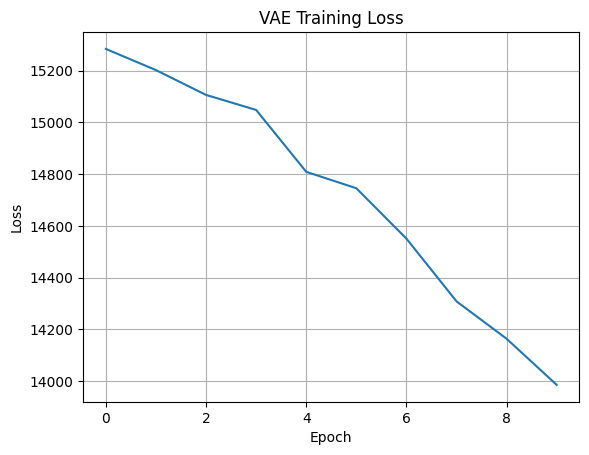

In [32]:
# Plot the Loss

plt.figure()
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Training Loss")
plt.grid()
plt.show()

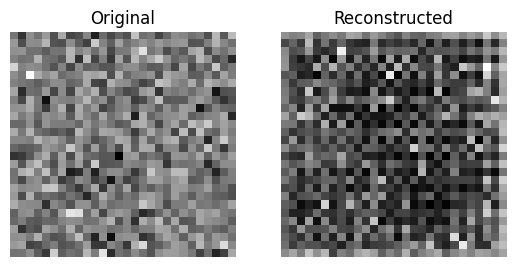

In [33]:
# Visualize re-construction 
with torch.no_grad():
    recon, _, _ = model(x)

# Pick first image
original = x[0].squeeze()
reconstructed = recon[0].squeeze()

plt.figure()
plt.subplot(1,2,1)
plt.imshow(original.numpy(), cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(reconstructed.numpy(), cmap="gray")
plt.title("Reconstructed")
plt.axis("off")

plt.show()


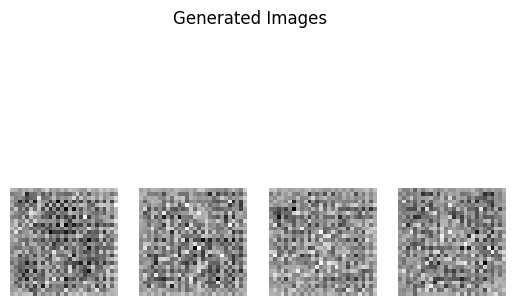

In [34]:
# Visualize New Image
with torch.no_grad():
    z = torch.randn(4, latent_dim)
    generated = model.decoder(z)

plt.figure()

for i in range(4):
    plt.subplot(1,4,i+1)
    plt.imshow(generated[i].squeeze().numpy(), cmap="gray")
    plt.axis("off")

plt.suptitle("Generated Images")
plt.show()